## **Introduzione**

La seguente analisi è stata effettuata utilizzando un dataset che raccoglie i dati sui crimini registrati nella città di **Baltimora (Maryland, USA)** tra gli anni 2010 e 2017.
Il dataset contiene informazioni dettagliate su ogni evento criminale, tra cui **data, ora, tipologia di reato, localizzazione geografica, distretto di polizia e coordinate GPS**, coprendo un ampio periodo temporale.

L'obiettivo dell'analisi è quello di effettuare una clusterizzazione dei distretti di polizia basati sui loro profili di criminalità, utilizzando algoritmi di clustering come **K-Means**.

Per l'analisi verranno utilizzate librerie Python come **pandas, matplotlib, seaborn, numpy, scipy e sklearn**, che consentiranno di effettuare una **pulizia accurata dei dati, un'analisi esplorativa (EDA) e la modellazione del modello di clustering**.

**N.B.**: Per questioni di compatibilità con le versioni delle librerie, si consiglia di utilizzare la versione **3.12.4** di Python.

In [2]:
# Installazione dei pacchetti necessari
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
import geopandas as gpd
import folium
from folium.plugins import FastMarkerCluster
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import csr_matrix


### **Import del dataset**

Si inizia l'analisi importando il dataset in formato `.csv`, disponibile al seguente link ufficiale:
🔗 [City of Baltimore Crime Data](https://data.world/data-society/city-of-baltimore-crime-data)

Per avere una visualizzazione piu' dettagliata del dataset, si consiglia di visionare il file `timeseries.ipynb`, che contiene un'analisi delle feature del dataset.

### **Considerazioni preliminari**
Una prima analisi esplorativa (non mostrata qui) ha evidenziato la presenza di valori mancanti, colonne ridondanti e formati non uniformi (in particolare date, orari e coordinate geografiche).

**Caricamento e pulizia dei dati**
- Verranno rimosse le colonne non necessarie (`CrimeDate`, `Location`, `Neighborhood`, `Total Incidents`) e verranno rimosse righe con valori mancanti.
- La colonna `CrimeTime` (originariamente in formato H:M:S) verrà trasformata per estrarre solo l'ora. Quest'ultima verrà poi usata per creare una nuova colonna categorica, `HourBin`, che divide il giorno in quattro fasce: `Night`, `Morning`, `Afternoon` e `Evening`.
- Le coordinate di latitudine e longitudine verranno estratte dalla colonna `Location 1`, che verrà poi eliminata.
- I valori testuali nelle colonne `District` e `Description` verranno puliti, rimuovendo spazi e correggendo refusi.

In [3]:
# Lettura il dataset CSV
df = pd.read_csv("CrimeData.csv")

# Rimozione colonne non necessarie
df = df.drop(columns=['CrimeDate','Location', 'Neighborhood','Total Incidents'], axis=1)

# Conversione colonna "CrimeTime"
df['CrimeTime'] = pd.to_datetime(df['CrimeTime'], format='%H:%M:%S', errors='coerce').dt.hour

# Estrazione coordinate
df[['Latitude', 'Longitude']] = df['Location 1'].str.extract(r'\((.*), (.*)\)').astype(float)
df = df.drop(columns=['Location 1'])

# Uniformizzazione stringhe
df['Description'] = df['Description'].str.strip()
df['District'] = df['District'].str.strip().replace({
    'Central':'CENTRAL', 
    'NORTHESTERN':'NORTHEASTERN', 
    'SOUTHESTERN':'SOUTHEASTERN', 
    'Gay Street': 'EASTERN'
})
# Standardizzazione più chiara di Inside/Outside
io_map = {'I': 'Inside', 'Inside': 'Inside', 'O': 'Outside', 'Outside': 'Outside'}
df['Inside/Outside'] = df['Inside/Outside'].map(io_map)

# Creazione fasce orarie
bins  = [-0.1, 5, 11, 17, 23]
labs  = ['Night','Morning','Afternoon','Evening']
df['HourBin'] = pd.cut(df['CrimeTime'], bins=bins, labels=labs)

# Rimozione delle righe con valori nulli
df = df.dropna()

# Visualizzazione informazioni sul dataset dopo la pulizia
print("Totale righe dopo pulizia:", len(df))
df.head(10)

Totale righe dopo pulizia: 90865


,CrimeTime,CrimeCode,Description,Inside/Outside,Weapon,Post,District,Latitude,Longitude,HourBin
1,2.0,3CF,ROBBERY - COMMERCIAL,Inside,FIREARM,213.0,SOUTHEASTERN,39.28242,-76.59288,Night
5,3.0,4E,COMMON ASSAULT,Inside,HANDS,423.0,NORTHEASTERN,39.37070,-76.56709,Night
6,3.0,3CO,ROBBERY - COMMERCIAL,Outside,OTHER,933.0,SOUTHERN,39.28624,-76.64455,Night
9,8.0,4E,COMMON ASSAULT,Inside,HANDS,743.0,WESTERN,39.30340,-76.63842,Morning
11,9.0,4E,COMMON ASSAULT,Inside,HANDS,813.0,SOUTHWESTERN,39.30587,-76.67216,Morning
12,9.0,4E,COMMON ASSAULT,Inside,HANDS,312.0,EASTERN,39.29883,-76.61042,Morning
14,11.0,4E,COMMON ASSAULT,Inside,HANDS,444.0,NORTHEASTERN,39.32120,-76.53906,Morning
17,11.0,4B,AGG. ASSAULT,Outside,KNIFE,714.0,WESTERN,39.28810,-76.64888,Morning
19,0.0,3AF,ROBBERY - STREET,Outside,FIREARM,733.0,WESTERN,39.31249,-76.64539,Night
20,0.0,3AF,ROBBERY - STREET,Outside,FIREARM,733.0,WESTERN,39.31249,-76.64539,Night


### Codifica delle variabili categoriche e standardizzazione delle feature

Per poter applicare algoritmi di clustering basati su distanze (come **DBSCAN**), è necessario trasformare tutte le variabili in formato numerico. Nel dataset sono presenti alcune feature **categoriche** (ad esempio tipologia di crimine, arma utilizzata, fascia oraria e luogo Inside/Outside), che non possono essere utilizzate direttamente nel calcolo della distanza euclidea.

In questa fase vengono quindi eseguiti due passaggi principali:

1. **Label Encoding delle feature categoriche**  
   Ogni valore testuale viene convertito in un intero (0, 1, 2, …). Questa trasformazione rende le colonne compatibili con gli algoritmi di clustering, pur mantenendo l’informazione di appartenenza a una determinata categoria.

2. **Selezione delle feature e standardizzazione**  
   Vengono selezionate sei feature complessive: le coordinate geografiche (**Latitude**, **Longitude**) e le quattro variabili categoriche codificate. Poiché queste feature presentano scale numeriche differenti, viene applicato lo **StandardScaler**, che normalizza i dati portando ogni variabile ad avere media pari a 0 e deviazione standard pari a 1. In questo modo si evita che alcune feature influenzino in maniera sproporzionata il calcolo delle distanze.

> **Nota**: il Label Encoding assegna codici numerici alle categorie senza introdurre un reale significato ordinale. Tale scelta è funzionale alla trasformazione dei dati in formato numerico; l’interpretazione dei risultati verrà successivamente effettuata riconducendo i codici alle categorie originali.

In [47]:
# Feature categoriche da labelizzare
categorical_cols = ['Description','Weapon','HourBin', 'Inside/Outside']

# Label encoding 
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col])
    encoders[col] = le

X = df[['Latitude', 'Longitude', 'Description_encoded', 'Weapon_encoded', 'HourBin_encoded', 'Inside/Outside_encoded']].values

# Standardizzazione delle feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:10])


[[-0.43418622  0.58800234  1.35780806 -1.32720718  1.50128174 -0.91335176]
 [ 1.11190501  1.20844362 -0.24600023 -0.24588445  1.50128174 -0.91335176]
 [-0.36728467 -0.65504541  1.35780806  1.91676101  1.50128174  1.09486843]
 [-0.06675312 -0.50757332 -0.24600023 -0.24588445  0.60121599 -0.91335176]
 [-0.02349479 -1.31927122 -0.24600023 -0.24588445  0.60121599 -0.91335176]
 [-0.14678978  0.1660349  -0.24600023 -0.24588445  0.60121599 -0.91335176]
 [ 0.24498707  1.88277356 -0.24600023 -0.24588445  0.60121599 -0.91335176]
 [-0.33470957 -0.7592141  -0.78060299  0.83543828  0.60121599  1.09486843]
 [ 0.09244454 -0.67525365  2.42701359 -1.32720718  1.50128174  1.09486843]
 [ 0.09244454 -0.67525365  2.42701359 -1.32720718  1.50128174  1.09486843]]


### Interpretazione del risultato della standardizzazione

L’output mostra le prime righe della matrice delle feature **standardizzate** (`X_scaled`). Ogni riga rappresenta un singolo evento criminale, mentre ogni colonna corrisponde a una delle sei feature selezionate (coordinate geografiche e variabili categoriche codificate).

Questa rappresentazione standardizzata costituisce quindi lo spazio delle feature su cui verrà applicato l’algoritmo **DBSCAN**, garantendo che la nozione di “vicinanza” tra eventi rifletta una combinazione equilibrata di posizione, tipologia di crimine, arma, fascia oraria e contesto Inside/Outside.


### **Clustering con DBScan** ###

Si procede con una prima fase di processamento dei dati con DBScan per eliminare il rumore e gli outlier presenti nel dataset per poi proseguire con **K-Means** per ottenere il numero di macro cluster.

### Stima del parametro *eps* tramite Nearest Neighbors (K-Distance Plot)

L’algoritmo **DBSCAN** richiede la definizione di due parametri fondamentali:  
- `eps`, che rappresenta il raggio massimo entro cui i punti vengono considerati “vicini”;  
- `min_samples`, che definisce il numero minimo di punti necessari per identificare una regione densa.

Per stimare in modo empirico un valore appropriato di `eps`, viene utilizzato il **K-Distance Plot**, basato sull’algoritmo dei **Nearest Neighbors**.

Il procedimento è il seguente:
- per ogni punto del dataset standardizzato viene calcolata la distanza dal suo *k-esimo* vicino più prossimo, dove `k` coincide con il valore scelto per `min_samples`;
- le distanze così ottenute vengono ordinate in modo crescente;
- il grafico risultante consente di individuare un punto di flesso (“gomito”), che separa le regioni dense del dataset dal rumore.

Il valore di `eps` viene quindi scelto in prossimità di questo punto di flesso, immediatamente prima dell’aumento rapido delle distanze, in modo da includere le regioni ad alta densità ed escludere i punti isolati.

Nel caso in esame, il grafico viene calcolato utilizzando `k = 40`, coerentemente con il valore di `min_samples` adottato successivamente in DBSCAN.


Dati campionati: 90865 punti


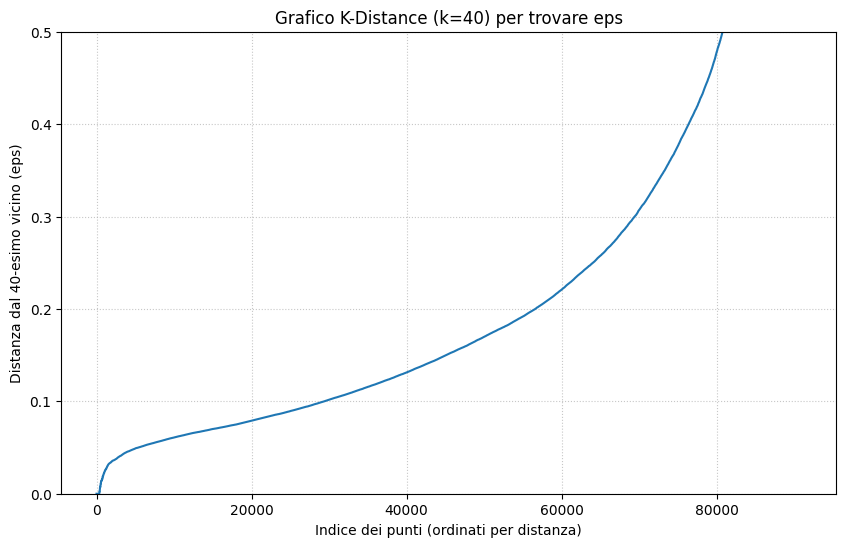

In [48]:
print(f"Dati campionati: {len(X_scaled)} punti")

# Calcolo delle distanze al k-esimo vicino più vicino
k = 40
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

# Plot del grafico
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title(f'Grafico K-Distance (k={k}) per trovare eps')
plt.xlabel("Indice dei punti (ordinati per distanza)")
plt.ylabel(f"Distanza dal {k}-esimo vicino (eps)")
plt.grid(True, linestyle=':', alpha=0.7)
plt.ylim(0, 0.5)
plt.show()

### Interpretazione del K-Distance Plot e scelta di *eps*

Il grafico K-Distance rappresenta, per ogni punto del dataset, la distanza dal suo **40-esimo vicino più prossimo**, con i punti ordinati in modo crescente rispetto a tale distanza.

L’andamento della curva può essere suddiviso in tre regioni principali:

1. **Tratto iniziale (pendenza bassa)**  
   Nella prima parte del grafico le distanze crescono lentamente e rimangono molto contenute.  
   Questa zona rappresenta i punti che si trovano in **regioni ad alta densità**, ovvero eventi molto simili tra loro nello spazio delle feature. Questi punti sono i candidati ideali a diventare **core points** in DBSCAN.

2. **Zona di transizione (punto di flesso)**  
   Intorno a valori di distanza compresi approssimativamente tra **0.20 e 0.25** si osserva un cambio evidente nella pendenza della curva.  
   Questo punto di flesso (o “gomito”) separa le regioni dense dal rumore ed è il riferimento principale per la scelta del parametro `eps`.

3. **Tratto finale (pendenza elevata)**  
   Nella parte finale del grafico la distanza cresce rapidamente.  
   Questi punti corrispondono a osservazioni **isolate o poco dense**, che DBSCAN tende a classificare come **rumore (outlier)** se `eps` viene scelto in prossimità del gomito.

Sulla base di questa analisi, un valore di `eps` compreso tra **0.22 e 0.25** risulta una scelta coerente:
- sufficientemente grande da includere le regioni dense;
- sufficientemente piccolo da escludere i punti isolati.

Il valore definitivo di `eps` verrà quindi scelto all’interno di questo intervallo e validato osservando la distribuzione dei cluster e la quantità di rumore prodotta da DBSCAN.


### Clustering degli eventi con DBSCAN (identificazione di hotspot)

Ora si applica l’algoritmo **DBSCAN** allo spazio delle feature standardizzate (`X_scaled`).

A differenza di K-Means, DBSCAN non richiede di fissare a priori il numero di cluster. Invece, individua automaticamente:
- **regioni ad alta densità** (interpretate come *hotspot*),
- e separa i punti **isolati o poco densi**, etichettandoli come **rumore**.

Nel modello vengono impostati:
- `eps = 0.25`, raggio massimo entro cui due punti sono considerati “vicini” nello spazio delle feature;
- `min_samples = 40`, numero minimo di punti necessari per considerare un’area come “densa” (coerente con il valore di `k` usato nel K-distance plot).

DBSCAN restituisce un’etichetta per ogni evento:
- `-1` indica **rumore** (evento non appartenente a nessun hotspot);
- `0, 1, 2, ...` indicano l’appartenenza a uno specifico **cluster/hotspot**.


In [50]:
# Definizione dei parametri DBSCAN
EPSILON = 0.25
MIN_SAMPLES = 40

# Esecuzione di DBSCAN
db = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES, metric='euclidean')
cluster_db = db.fit_predict(X_scaled)

# Aggiunta dei risultati di DBSCAN al DataFrame originale
df['cluster'] = cluster_db

print("Punti per cluster (hotspot): (-1 = Rumore/Non-Hotspot)")
print(df['cluster'].value_counts())

# Informazioni riassuntive (molto utili in relazione)
n_clusters = len(set(cluster_db)) - (1 if -1 in cluster_db else 0)
noise_pct = (df['cluster'].eq(-1).mean() * 100)

print(f"\nCluster trovati (escluso rumore): {n_clusters}")
print(f"Percentuale di rumore: {noise_pct:.1f}%")

Punti per cluster (hotspot): (-1 = Rumore/Non-Hotspot)
cluster
-1     19389
 8      8920
 7      8475
 0      6738
 11     5867
       ...  
 79       40
 83       40
 77       40
 73       26
 74       26
Name: count, Length: 86, dtype: int64

Cluster trovati (escluso rumore): 85
Percentuale di rumore: 21.3%


### Interpretazione dei risultati di DBSCAN

L’output mostra la distribuzione dei punti tra i cluster individuati da DBSCAN. In particolare:

- Il valore `-1` rappresenta gli eventi classificati come **rumore** (non appartenenti ad alcuna regione densa).  
  In questo caso il rumore è pari a **19.389 eventi**, che corrisponde a circa **~20%** del dataset: un valore plausibile per DBSCAN su dati reali e ad alta variabilità.

- I cluster con etichetta `0, 7, 8, 11, ...` rappresentano invece gli **hotspot**, cioè gruppi di eventi simili tra loro nello spazio delle feature (posizione + variabili categoriali codificate).  
  Si osservano alcuni cluster molto grandi (ad esempio ~8.9k e ~8.5k eventi), che indicano pattern ripetuti e consistenti nel dataset.

- È presente anche una “coda” di cluster piccoli (es. con ~40 punti o meno). Questo comportamento è normale in DBSCAN: `min_samples` non impone una dimensione minima del cluster, ma stabilisce la densità minima richiesta per identificare almeno un *core point*. Alcuni cluster possono quindi risultare piccoli pur essendo generati da micro-aree localmente dense.

Nel complesso, DBSCAN sta individuando:
1. **pochi hotspot principali** (cluster grandi e stabili),
2. **diversi pattern locali** (cluster piccoli),
3. e una quota di **eventi isolati** (rumore), che verranno esclusi nelle analisi successive sugli hotspot.


### Rimozione del rumore e costruzione del dataset “pulito”

Dopo aver applicato DBSCAN, il dataset risulta suddiviso in:
- **eventi appartenenti a cluster densi** (hotspot),
- **eventi classificati come rumore** (etichetta `-1`).

Poiché l’obiettivo della fase successiva è applicare **K-Means** per individuare strutture globali e confrontabili, è opportuno rimuovere il rumore individuato da DBSCAN.  
In questo modo, K-Means viene applicato **solo ai punti informativi**, evitando che osservazioni isolate o anomale influenzino la posizione dei centroidi.


In [53]:
# Maschera: True per punti NON rumore (cluster DBSCAN diversi da -1)
mask = df['cluster'] != -1

# Dataset pulito (solo punti appartenenti a hotspot)
X_scaled_clean = X_scaled[mask.values]

# Etichette DBSCAN dei punti rimanenti
labels_clean = df.loc[mask, 'cluster'].values

# DataFrame originale filtrato dai punti di rumore
df_clean = df[mask].copy()

print("Dimensioni del dataset pulito:", X_scaled_clean.shape)

# DataFrame numerico standardizzato (input per K-Means)
new_df = pd.DataFrame(
    X_scaled_clean,
    columns=[
        'Latitude', 'Longitude',
        'Description_encoded', 'Weapon_encoded',
        'HourBin_encoded', 'Inside/Outside_encoded'
    ]
)


Dimensioni del dataset pulito: (71476, 6)


### Scelta del numero ottimale di cluster per K-Means

Dopo aver rimosso il rumore tramite DBSCAN, il clustering con **K-Means** viene applicato esclusivamente ai punti appartenenti a regioni dense (hotspot).

Poiché K-Means richiede di specificare a priori il numero di cluster `K`, viene effettuata un’analisi preliminare per individuare il valore più appropriato utilizzando due metriche complementari:

- **Metodo Elbow (Inertia)**: misura la somma delle distanze quadratiche dei punti dal centroide del cluster di appartenenza.  
  Un valore ottimale di `K` è spesso associato a un “gomito” nella curva, oltre il quale la riduzione dell’inerzia diventa marginale.

- **Silhouette Score**: valuta quanto ogni punto è simile al proprio cluster rispetto agli altri.  
  Valori più alti indicano cluster più compatti e meglio separati.

L’analisi viene eseguita su un intervallo di valori di `K` compreso tra 2 e 7, utilizzando come input il dataset pulito ottenuto dopo DBSCAN.


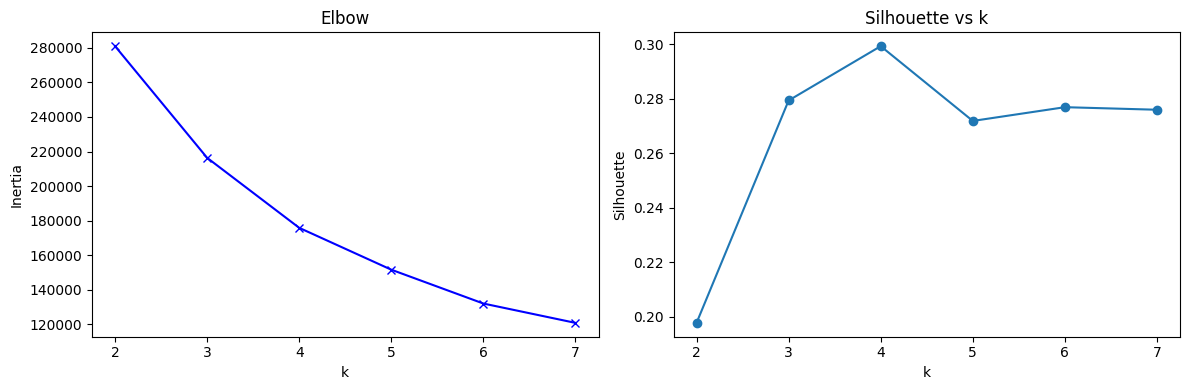

In [54]:
# Elbow Method per determinare il valore ottimale di k
distorsions = []
silhouettes = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, n_init='auto', random_state=0)
    labels = km.fit_predict(new_df)
    distorsions.append(km.inertia_)
    silhouettes.append(silhouette_score(new_df, labels))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K, distorsions, 'bx-')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow')

plt.subplot(1,2,2)
plt.plot(K, silhouettes, 'o-')
plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('Silhouette vs k')
plt.tight_layout(); plt.show()

### Interpretazione dei grafici Elbow e Silhouette

I grafici ottenuti permettono di valutare il numero ottimale di cluster `K` per l’algoritmo K-Means applicato al dataset filtrato da DBSCAN.

**Metodo Elbow**  
Il grafico dell’inerzia mostra una riduzione molto marcata passando da `K = 2` a `K = 4`.  
A partire da `K = 4`, la diminuzione dell’inerzia diventa progressivamente più contenuta e quasi lineare, indicando che l’aggiunta di ulteriori cluster non porta a un miglioramento significativo nella compattezza dei gruppi.

Questo comportamento suggerisce la presenza di un “gomito” in corrispondenza di **K = 4**, oltre il quale l’aumento della complessità del modello produce benefici marginali.

**Silhouette Score**  
Il grafico del Silhouette Score mostra un incremento netto da `K = 2` a `K = 4`, dove si raggiunge il **valore massimo** (circa 0.30).  
Per valori di `K` superiori a 4, il Silhouette Score diminuisce leggermente o rimane stabile, indicando una qualità di separazione dei cluster inferiore o non migliorativa.

**Scelta finale di K**  
Considerando congiuntamente:
- il punto di flesso individuato dal metodo Elbow,
- il massimo valore del Silhouette Score,

il valore **K = 4** risulta essere il compromesso migliore tra:
- qualità della separazione dei cluster,
- compattezza interna,
- semplicità del modello.

Pertanto, nelle analisi successive, K-Means verrà eseguito utilizzando **4 cluster** sul dataset ripulito dal rumore tramite DBSCAN.


### Esecuzione di K-Means sugli eventi (dataset filtrato)

Dopo aver determinato il valore ottimale di `K` tramite Elbow e Silhouette, si esegue ora il clustering **K-Means con K = 4** sul dataset ripulito dal rumore attraverso DBSCAN (`new_df`).

In questa fase:
- ogni evento viene assegnato a uno dei 4 cluster individuati da K-Means;
- le etichette risultanti vengono aggiunte al dataset originale filtrato (`df_clean`) in una nuova colonna (`event_cluster`).

L’obiettivo è ottenere una partizione globale degli eventi “non rumorosi”, utile per interpretare i profili dei cluster.


In [57]:
# === Fit KMeans e assegnazione agli eventi ===
k_opt1 = 4
kmeans = KMeans(n_clusters=k_opt1, n_init='auto', random_state=0)
labels = kmeans.fit_predict(new_df)

df_kmeans = df_clean.copy()
df_kmeans['event_cluster'] = labels
# Conteggio dei valori per ogni cluster
print(df_kmeans['event_cluster'].value_counts().sort_index())
df_kmeans.head(10)

event_cluster
0     8738
1    21411
2    34578
3     6749
Name: count, dtype: int64


,CrimeTime,CrimeCode,Description,Inside/Outside,Weapon,Post,District,Latitude,Longitude,HourBin,Description_encoded,Weapon_encoded,HourBin_encoded,Inside/Outside_encoded,cluster,event_cluster
5,3.0,4E,COMMON ASSAULT,Inside,HANDS,423.0,NORTHEASTERN,39.37070,-76.56709,Night,1,1,3,0,0,2
9,8.0,4E,COMMON ASSAULT,Inside,HANDS,743.0,WESTERN,39.30340,-76.63842,Morning,1,1,2,0,1,2
11,9.0,4E,COMMON ASSAULT,Inside,HANDS,813.0,SOUTHWESTERN,39.30587,-76.67216,Morning,1,1,2,0,1,2
12,9.0,4E,COMMON ASSAULT,Inside,HANDS,312.0,EASTERN,39.29883,-76.61042,Morning,1,1,2,0,1,2
14,11.0,4E,COMMON ASSAULT,Inside,HANDS,444.0,NORTHEASTERN,39.32120,-76.53906,Morning,1,1,2,0,1,2
19,0.0,3AF,ROBBERY - STREET,Outside,FIREARM,733.0,WESTERN,39.31249,-76.64539,Night,6,0,3,1,2,3
20,0.0,3AF,ROBBERY - STREET,Outside,FIREARM,733.0,WESTERN,39.31249,-76.64539,Night,6,0,3,1,2,3
23,1.0,4C,AGG. ASSAULT,Outside,OTHER,323.0,EASTERN,39.30038,-76.58101,Night,0,3,3,1,3,0
24,1.0,4B,AGG. ASSAULT,Outside,KNIFE,323.0,EASTERN,39.30128,-76.58385,Night,0,2,3,1,4,1
27,12.0,4E,COMMON ASSAULT,Outside,HANDS,425.0,NORTHEASTERN,39.34513,-76.54164,Afternoon,1,1,0,1,5,1


### Distribuzione degli eventi nei cluster K-Means

Il risultato mostra il numero di eventi assegnati a ciascun cluster K-Means:

- **Cluster 0**: 8.738 eventi  
- **Cluster 1**: 21.411 eventi  
- **Cluster 2**: 34.578 eventi  
- **Cluster 3**: 6.749 eventi  

La distribuzione non è uniforme: alcuni cluster (in particolare il Cluster 2) raccolgono una quota maggiore di eventi, suggerendo la presenza di un pattern più frequente o “generico” nel dataset filtrato.  
Al contrario, cluster più piccoli (Cluster 3 e Cluster 0) potrebbero rappresentare modalità di crimine più specifiche o meno ricorrenti.

Nei passaggi successivi, la composizione dei cluster verrà analizzata e interpretata tramite:
- tecniche di visualizzazione (PCA),
- e confronto delle feature dominanti per ciascun cluster.


### Visualizzazione e interpretazione dei cluster tramite PCA

Per supportare l’interpretazione dei cluster ottenuti con K-Means, viene applicata la **Principal Component Analysis (PCA)** al dataset standardizzato e filtrato (`new_df`).

La PCA consente di:
- ridurre la dimensionalità dei dati,
- proiettare gli eventi in uno spazio a 2 dimensioni,
- analizzare quali variabili contribuiscono maggiormente alla separazione dei cluster.

È importante sottolineare che la PCA **non viene utilizzata per il clustering**, ma esclusivamente come strumento di analisi e interpretazione dei risultati prodotti da K-Means.

In questa analisi viene mostrata la proiezione sulle **prime due componenti principali**, che spiegano la quota maggiore di varianza complessiva.


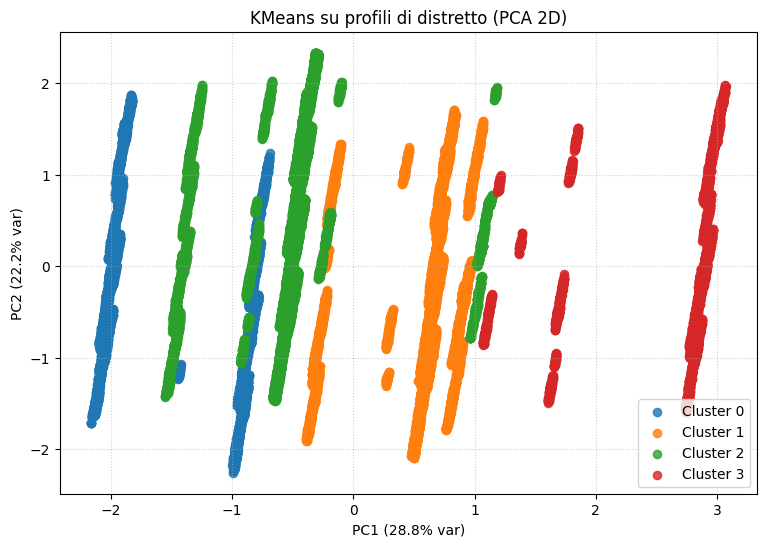

=== PC1 (28.8%) - Cosa sposta i punti a destra/sinistra? ===
--- Spingono a DESTRA (Valori Alti) ---
Description_encoded       0.610965
Inside/Outside_encoded    0.568960
HourBin_encoded           0.061777
Longitude                 0.043927
Latitude                  0.016114
Name: PC1, dtype: float64

--- Spingono a SINISTRA (Valori Bassi) ---
Weapon_encoded           -0.544978
Latitude                  0.016114
Longitude                 0.043927
HourBin_encoded           0.061777
Inside/Outside_encoded    0.568960
Name: PC1, dtype: float64

=== PC2 (22.2%) - Cosa sposta i punti in alto/basso? ===
--- Spingono in ALTO (Valori Alti) ---
HourBin_encoded        0.880827
Longitude              0.323539
Description_encoded    0.058069
Latitude              -0.010022
Weapon_encoded        -0.135488
Name: PC2, dtype: float64

--- Spingono in BASSO (Valori Bassi) ---
Inside/Outside_encoded   -0.312468
Weapon_encoded           -0.135488
Latitude                 -0.010022
Description_encoded    

In [58]:
# === PCA per visualizzare in 2D ===
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(new_df)

plt.figure(figsize=(9,6))
for c in np.unique(labels):
    plt.scatter(
        X_pca[labels == c, 0],
        X_pca[labels == c, 1],
        s=35,
        alpha=0.8,
        label=f'Cluster {c}')

plt.title('KMeans su profili di distretto (PCA 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Crea un DataFrame dei 'loadings' (pesi)
loadings = pd.DataFrame(
    pca.components_.T,  # .T per avere le feature come righe
    columns=['PC1', 'PC2'],
    index=new_df.columns
)

# Stampa le feature più influenti per PC1 (Asse X)
print(f"=== PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) - Cosa sposta i punti a destra/sinistra? ===")
print("--- Spingono a DESTRA (Valori Alti) ---")
print(loadings['PC1'].sort_values(ascending=False).head(5))
print("\n--- Spingono a SINISTRA (Valori Bassi) ---")
print(loadings['PC1'].sort_values(ascending=True).head(5))

# Stampa le feature più influenti per PC2 (Asse Y)
print(f"\n=== PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%) - Cosa sposta i punti in alto/basso? ===")
print("--- Spingono in ALTO (Valori Alti) ---")
print(loadings['PC2'].sort_values(ascending=False).head(5))
print("\n--- Spingono in BASSO (Valori Bassi) ---")
print(loadings['PC2'].sort_values(ascending=True).head(5))

### Analisi della proiezione PCA in due dimensioni

Il grafico mostra la distribuzione degli eventi nei primi due assi principali (PC1 e PC2), colorati in base al cluster di appartenenza.

Visivamente, i cluster risultano parzialmente sovrapposti e disposti lungo bande quasi verticali. Questo comportamento è coerente con la natura dei dati:
- molte feature sono **categoriche label-encodate**,
- la PCA proietta combinazioni lineari di tali variabili,
- la separazione non è necessariamente “pulita” nello spazio bidimensionale.

Di conseguenza, il valore informativo principale della PCA non risiede tanto nella separazione visiva dei punti, quanto nell’**analisi dei contributi delle variabili alle componenti principali**, riportata di seguito.


### Interpretazione delle componenti principali (PC1 e PC2)

Le componenti principali permettono di comprendere **quali variabili guidano la struttura dei cluster**.

#### PC1 – Asse orizzontale (28.8% della varianza)
La prima componente principale è fortemente influenzata da:
- `Description_encoded` (peso positivo elevato),
- `Inside/Outside_encoded`,
- in misura minore da `HourBin_encoded`.

Valori elevati di PC1 sono quindi associati a:
- specifiche tipologie di reato,
- una forte distinzione tra eventi avvenuti **all’interno o all’esterno**.

Al contrario, valori bassi di PC1 sono principalmente guidati da:
- `Weapon_encoded` (peso negativo rilevante),

suggerendo che questa componente separa gli eventi in base a **modalità del crimine e contesto**, più che alla localizzazione geografica.

#### PC2 – Asse verticale (22.2% della varianza)
La seconda componente principale è dominata da:
- `HourBin_encoded`, che presenta il contributo più elevato in assoluto.

Questo indica che PC2 rappresenta principalmente una **dimensione temporale**, distinguendo gli eventi in base alla fascia oraria in cui si verificano.

Contributi secondari sono dati da:
- `Longitude` e, in misura minore, `Description_encoded`,
mentre `Inside/Outside_encoded` contribuisce negativamente, spostando i punti verso valori più bassi dell’asse.

Nel complesso:
- **PC1** cattura differenze legate al **tipo di reato e al contesto (interno/esterno)**;
- **PC2** cattura differenze legate prevalentemente al **momento temporale del crimine**.

Questo conferma che i cluster K-Means sono guidati principalmente da **caratteristiche comportamentali e temporali**, più che dalla sola posizione geografica.


### Costruzione dei profili dei cluster

I cluster ottenuti con K-Means sono stati calcolati utilizzando feature numeriche (coordinate + variabili categoriche codificate e standardizzate).  
Tuttavia, per interpretare **il significato reale dei cluster** è necessario tornare a variabili leggibili e confrontabili, come le categorie originali di:

- tipo di reato (`Description`)
- arma (`Weapon`)
- fascia oraria (`HourBin`)
- contesto (`Inside/Outside`)

In questa fase si procede quindi a:

1. eliminare le colonne `_encoded` (utili solo per il clustering numerico);
2. applicare il **One-Hot Encoding** alle colonne categoriche originali;
3. ottenere una rappresentazione binaria (0/1) per ogni categoria, che consente poi di calcolare facilmente **frequenze/percentuali** per cluster.

L’obiettivo è preparare i dati per calcolare, in seguito, la **media per cluster** delle colonne one-hot: tale media corrisponderà alla percentuale di eventi del cluster che appartiene a ciascuna categoria (profilo del cluster).


In [ ]:
# Pulizia del dataframe finale con i cluster di Kmeans
# elimino le colonne _encoded e la colonna cluster
cleaned_clustered_values = df_kmeans.drop(columns=['Description_encoded', 'Weapon_encoded', 'HourBin_encoded', 'Inside/Outside_encoded', 'cluster'])

# Categorie per fare il profilo
cat_cols = ['Description','Weapon','HourBin', 'Inside/Outside']

# One-hot encoding (dummies)
dummies = pd.get_dummies(cleaned_clustered_values[cat_cols], drop_first=False)

# Concatenazione dei dummies al dataframe pulito
cleaned_clustered_values = pd.concat([cleaned_clustered_values['event_cluster'].reset_index(drop=True), dummies.reset_index(drop=True)], axis=1)

cleaned_clustered_values.head(10)


,event_cluster,Description_AGG. ASSAULT,Description_COMMON ASSAULT,Description_RAPE,Description_ROBBERY - COMMERCIAL,Description_ROBBERY - RESIDENCE,Description_ROBBERY - STREET,Weapon_FIREARM,Weapon_HANDS,Weapon_KNIFE,Weapon_OTHER,HourBin_Night,HourBin_Morning,HourBin_Afternoon,HourBin_Evening,Inside/Outside_Inside,Inside/Outside_Outside
0,2,False,True,False,False,False,False,False,True,False,False,True,False,False,False,True,False
1,2,False,True,False,False,False,False,False,True,False,False,False,True,False,False,True,False
2,2,False,True,False,False,False,False,False,True,False,False,False,True,False,False,True,False
3,2,False,True,False,False,False,False,False,True,False,False,False,True,False,False,True,False
4,2,False,True,False,False,False,False,False,True,False,False,False,True,False,False,True,False
5,3,False,False,False,False,False,True,True,False,False,False,True,False,False,False,False,True
6,3,False,False,False,False,False,True,True,False,False,False,True,False,False,False,False,True
7,0,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True
8,1,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True
9,1,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True


A questo punto il dataset contiene:
- la colonna `event_cluster`,
- e un insieme di colonne binarie ottenute dal One-Hot Encoding.

Ogni riga rappresenta un evento; le colonne one-hot valgono 1 se l’evento appartiene a quella categoria, altrimenti 0.

Il passo successivo consiste nel **raggruppare per `event_cluster` e calcolare la media** delle colonne one-hot:  
la media di una colonna binaria corrisponde alla **percentuale** di eventi del cluster che appartiene a quella categoria, ottenendo così un **profilo interpretabile del cluster**.


### Creazione dei profili percentuali dei cluster

Dopo aver trasformato le variabili categoriche in colonne binarie tramite **One-Hot Encoding**, è possibile costruire un profilo sintetico per ciascun cluster K-Means.

Il principio è semplice:  
poiché ogni colonna one-hot vale **1** se l’evento appartiene a quella categoria e **0** altrimenti, la **media** di quella colonna all’interno di un cluster corrisponde alla **percentuale di eventi** del cluster che appartiene a quella categoria.

Esempio:
- se in un cluster la colonna `Weapon_HANDS` ha media `0.77`, significa che **il 77% degli eventi** di quel cluster coinvolge “Hands”.

Per ottenere questi profili, si raggruppano i dati per `event_cluster` e si calcola la media delle colonne binarie.


In [ ]:
# Aggrego per cluster calcolando i profili percentuali

# Unità di aggregazione: Cluster
profile = cleaned_clustered_values.groupby('event_cluster', as_index=True).mean()

print(profile.round(3))

               Description_AGG. ASSAULT  Description_COMMON ASSAULT  \
event_cluster                                                         
0                                 0.993                       0.000   
1                                 0.243                       0.757   
2                                 0.114                       0.863   
3                                 0.000                       0.000   

               Description_RAPE  Description_ROBBERY - COMMERCIAL  \
event_cluster                                                       
0                         0.007                             0.000   
1                         0.000                             0.000   
2                         0.000                             0.022   
3                         0.000                             0.000   

               Description_ROBBERY - RESIDENCE  Description_ROBBERY - STREET  \
event_cluster                                                                 

### Interpretazione dei profili dei cluster (percentuali)

La tabella risultante descrive, per ciascun cluster, la distribuzione percentuale delle categorie principali (tipo di reato, arma, fascia oraria e contesto Inside/Outside).  
Dall’output emergono profili molto distinti:

#### **Cluster 0 — “Aggressioni aggravate con arma non specificata (Other)”**
- `Description_AGG. ASSAULT ≈ 0.993` → quasi tutti gli eventi (99.3%) sono aggressioni aggravate.
- `Weapon_OTHER ≈ 0.9997` → l’arma è quasi sempre classificata come “Other”.
- `Inside/Outside` è bilanciato (≈ 51% inside, 49% outside).
- Fascia oraria più frequente: `Evening` (≈ 40.5%).

➡️ Cluster altamente specializzato: un pattern molto dominante legato alle **aggressioni aggravate**.

#### **Cluster 1 — “Common assault all’esterno”**
- `Description_COMMON ASSAULT ≈ 0.757` → la maggioranza (75.7%) è common assault.
- `Inside/Outside_Outside = 1.0` → tutti gli eventi avvengono **all’esterno**.
- Armi: prevale `Weapon_HANDS ≈ 0.773`, poi `FIREARM ≈ 0.124` e `KNIFE ≈ 0.103`.
- Distribuzione temporale abbastanza equilibrata, con picco su `Afternoon` ed `Evening`.

➡️ Cluster con una forte impronta “stradale”: **aggressioni comuni all’aperto**, spesso con mani e talvolta con armi.

#### **Cluster 2 — “Common assault all’interno”**
- `Description_COMMON ASSAULT ≈ 0.863` → common assault ancora più dominante (86.3%).
- `Inside/Outside_Inside = 1.0` → tutti gli eventi avvengono **all’interno**.
- Armi: soprattutto `Weapon_HANDS ≈ 0.888`, poi `KNIFE ≈ 0.079` e `FIREARM ≈ 0.033`.
- Nota: compare `ROBBERY - COMMERCIAL ≈ 0.022` (2.2%), piccola ma presente.

➡️ Profilo simile al Cluster 1, ma con differenza netta: **qui gli eventi sono interni**, non esterni.

#### **Cluster 3 — “Rapine in strada con armi da fuoco (prevalentemente)”**
- `Description_ROBBERY - STREET ≈ 0.992` → quasi tutte le osservazioni sono rapine in strada.
- Armi: `Weapon_FIREARM ≈ 0.869` → forte componente di armi da fuoco.
- `Inside/Outside_Outside ≈ 0.992` → quasi totalmente all’esterno.
- Fascia oraria dominante: `Evening ≈ 0.523` e anche `Night ≈ 0.292`.

➡️ Cluster estremamente caratterizzante: **rapine in strada all’esterno**, soprattutto **di sera/notte**, con alta presenza di **armi da fuoco**.

---

### Sintesi finale

I cluster ottenuti da K-Means risultano chiaramente interpretabili:

- due cluster “simili” per tipo di crimine (`COMMON ASSAULT`) ma separati dal contesto:
  - Cluster 1 = **Outside**
  - Cluster 2 = **Inside**
- un cluster altamente specifico su aggressioni aggravate (Cluster 0)
- un cluster altamente specifico su rapine in strada armate (Cluster 3)

Questa profilazione conferma che il clustering sta catturando pattern reali e distinti nei dati, soprattutto legati a **tipo di reato**, **arma** e **Inside/Outside**.


### Analisi descrittiva dei cluster tramite heatmap dei profili percentuali

La heatmap consente di:
- confrontare visivamente i cluster tra loro,
- individuare rapidamente le feature **più frequenti** all’interno di ciascun gruppo,
- ottenere una prima intuizione sulle differenze strutturali tra i cluster.

È importante sottolineare che questa analisi riflette **le frequenze assolute** delle variabili, senza tenere conto della loro rarità o diffusione nel dataset complessivo.


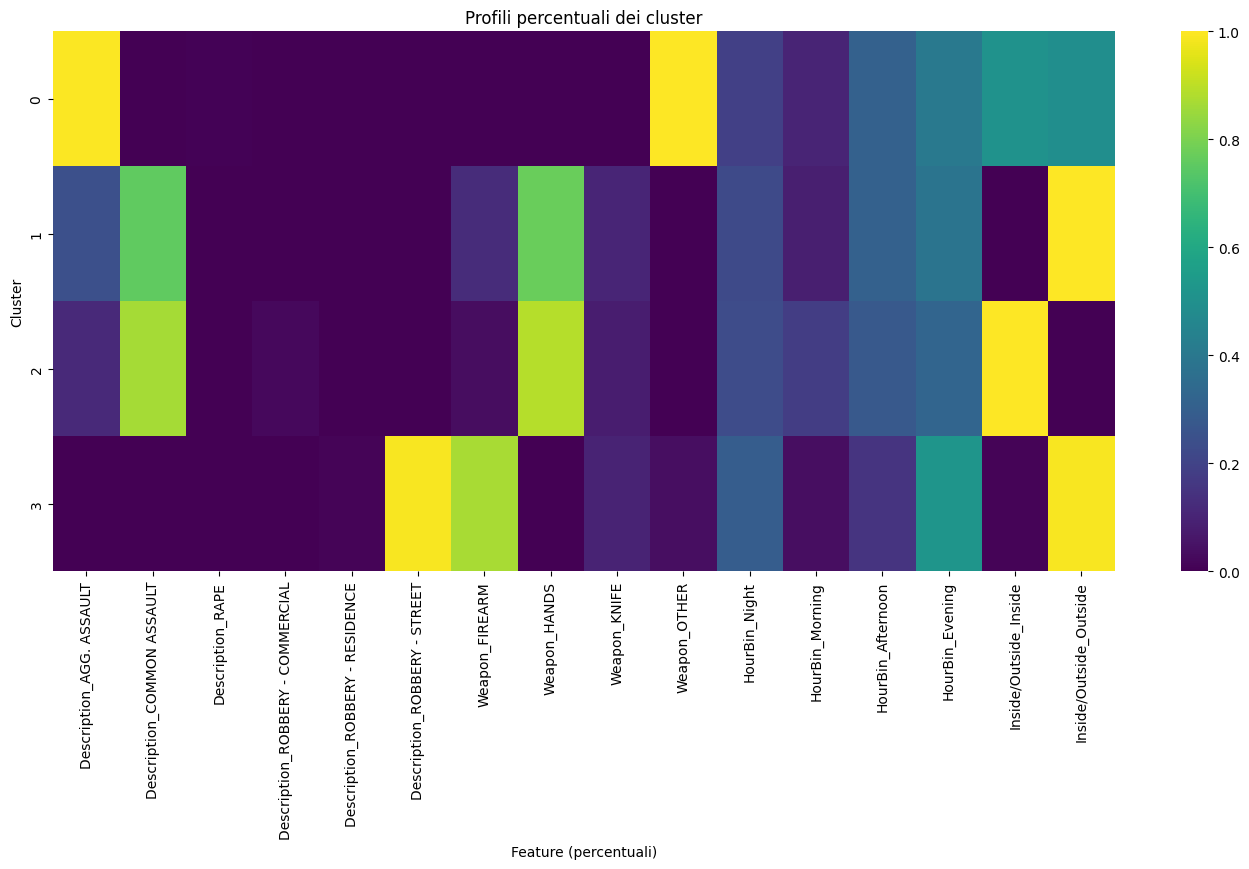

In [60]:
# === Heatmap dei centroidi per confronto rapido ===
plt.figure(figsize=(min(16, 0.5*len(profile.columns)+6), 1.2*k_opt1+4))
sns.heatmap(
    profile,
    cmap='viridis',
    annot=False,
    cbar=True
)
plt.title('Profili percentuali dei cluster')
plt.xlabel('Feature (percentuali)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

### Interpretazione della heatmap e limiti dell’analisi percentuale

Dalla heatmap emergono pattern chiari e coerenti con quanto osservato nei passaggi precedenti:

- alcuni cluster risultano dominati da specifiche tipologie di reato (ad esempio aggressioni comuni o rapine),
- la distribuzione delle armi e del contesto Inside/Outside evidenzia differenze marcate tra i cluster,
- le fasce orarie mostrano una certa variabilità, ma con trend abbastanza regolari.

Tuttavia, questa rappresentazione mette in evidenza **soprattutto le categorie più frequenti in assoluto** nel dataset.  
Di conseguenza:
- variabili rare (come `RAPE`, `ROBBERY - COMMERCIAL` o alcune tipologie di arma) appaiono poco rilevanti,
- non è possibile distinguere se una feature sia realmente *caratteristica* di un cluster o semplicemente comune ovunque.

In altre parole, la heatmap risponde alla domanda:
> *“Cosa accade più spesso all’interno di ciascun cluster?”*

ma non consente di rispondere a:
> *“Cosa rende questo cluster diverso dagli altri?”*

Per superare questo limite e ottenere una caratterizzazione più significativa dei cluster, viene introdotta l’analisi del **Lift**, che confronta la probabilità di ciascuna feature nel cluster rispetto alla media globale del dataset.


### Analisi del Lift: individuazione delle caratteristiche distintive dei cluster

L’analisi basata sulle percentuali (medie delle colonne one-hot) permette di comprendere quali categorie sono più frequenti all’interno di ciascun cluster. Tuttavia, questo approccio presenta un limite importante:  
le categorie molto comuni a livello globale tendono a dominare la rappresentazione, mentre eventi meno frequenti ma altamente caratterizzanti rischiano di essere sottovalutati.

Per superare questo limite, viene introdotta l’**analisi del Lift**.

Il Lift confronta, per ogni feature e per ogni cluster, la sua incidenza nel cluster rispetto alla **media globale dell’intero dataset**. In questo modo è possibile identificare non solo ciò che è frequente, ma soprattutto ciò che è **sovra-rappresentato** in un cluster rispetto al comportamento medio complessivo.

Formalmente:
- **Lift > 1** indica che una feature è più presente nel cluster rispetto alla media globale;
- **Lift = 1** indica una presenza in linea con la media;
- **Lift < 1** indica una sotto-rappresentazione.

Questa analisi consente di assegnare una “firma” chiara a ciascun cluster, evidenziandone le peculiarità reali.


In [41]:
# === LIFT rispetto alla media globale ===
global_mean = profile.mean()

lift = profile.copy()
for col in lift.columns:
    baseline = global_mean[col] if global_mean[col] != 0 else 1e-9
    lift[col] = lift[col] / baseline  # >1 = sopra la media globale

for c in lift.index:
    print(f'\n=== {c}: feature con lift più alto ===')
    print(
        lift.loc[c]
        .sort_values(ascending=False)
        .head(10)
        .round(2))


=== 0: feature con lift più alto ===
Description_RAPE            4.00
Weapon_OTHER                3.86
Description_AGG. ASSAULT    2.94
Inside/Outside_Inside       1.34
HourBin_Afternoon           1.18
HourBin_Morning             1.02
HourBin_Evening             0.99
HourBin_Night               0.81
Inside/Outside_Outside      0.79
Weapon_KNIFE                0.00
Name: 0, dtype: float64

=== 1: feature con lift più alto ===
Description_COMMON ASSAULT    1.87
Weapon_HANDS                  1.86
Inside/Outside_Outside        1.61
Weapon_KNIFE                  1.48
HourBin_Afternoon             1.18
HourBin_Night                 0.96
HourBin_Evening               0.94
HourBin_Morning               0.84
Description_AGG. ASSAULT      0.72
Weapon_FIREARM                0.48
Name: 1, dtype: float64

=== 2: feature con lift più alto ===
Description_ROBBERY - COMMERCIAL    4.00
Inside/Outside_Inside               2.64
Weapon_HANDS                        2.14
Description_COMMON ASSAULT         

### Interpretazione dettagliata dei risultati del Lift

L’analisi del Lift consente di individuare, per ciascun cluster, le caratteristiche **realmente distintive** rispetto alla media complessiva del dataset.  
Valori di Lift significativamente maggiori di 1 indicano feature che risultano sovra-rappresentate nel cluster, anche quando la loro frequenza assoluta è bassa.

Di seguito vengono analizzati i profili emersi.

---

#### **Cluster 0 — Aggressioni aggravate e reati rari**

Il Cluster 0 presenta valori di Lift estremamente elevati per:
- `Description_RAPE` (**Lift = 4.00**),
- `Weapon_OTHER` (**Lift = 3.86**),
- `Description_AGG. ASSAULT` (**Lift = 2.94**).

Sebbene alcune di queste categorie siano poco frequenti nel dataset complessivo, il Lift evidenzia come esse siano **fortemente concentrate** in questo cluster.  
Il contesto `Inside/Outside_Inside` risulta leggermente sovra-rappresentato (1.34), suggerendo una maggiore incidenza di eventi interni.

➡️ Questo cluster rappresenta un gruppo altamente specializzato, dominato da **aggressioni aggravate e reati particolarmente sensibili**, che emergono chiaramente solo grazie all’analisi del Lift.

---

#### **Cluster 1 — Aggressioni comuni all’esterno**

Nel Cluster 1 emergono come caratteristiche distintive:
- `Description_COMMON ASSAULT` (**Lift = 1.87**),
- `Weapon_HANDS` (**Lift = 1.86**),
- `Inside/Outside_Outside` (**Lift = 1.61**),
- `Weapon_KNIFE` (**Lift = 1.48**).

Il Lift conferma che, rispetto alla media globale, questo cluster è fortemente associato a **aggressioni comuni**, prevalentemente **all’esterno**, spesso senza armi da fuoco ma con l’uso di mani o coltelli.

➡️ Il cluster descrive un pattern tipico di **violenza urbana di bassa/media intensità**, ben distinto dagli altri gruppi.

---

#### **Cluster 2 — Reati interni e contesto mattutino**

Il Cluster 2 è caratterizzato da valori di Lift molto elevati per:
- `Description_ROBBERY - COMMERCIAL` (**Lift = 4.00**),
- `Inside/Outside_Inside` (**Lift = 2.64**),
- `Weapon_HANDS` (**Lift = 2.14**),
- `Description_COMMON ASSAULT` (**Lift = 2.13**),
- `HourBin_Morning` (**Lift = 1.78**).

Questi valori indicano che il cluster è fortemente associato a **reati che avvengono all’interno**, spesso in contesti commerciali e nelle **fasce orarie mattutine**.

➡️ Il Lift permette di distinguere chiaramente questo cluster dal Cluster 1, che pure condivide il tipo di reato (`COMMON ASSAULT`) ma in un contesto opposto (esterno).

---

#### **Cluster 3 — Rapine in strada con armi da fuoco**

Il Cluster 3 presenta i valori di Lift più marcati dell’intera analisi:
- `Description_ROBBERY - RESIDENCE` (**Lift = 4.00**),
- `Description_ROBBERY - STREET` (**Lift = 4.00**),
- `Weapon_FIREARM` (**Lift = 3.39**),
- `Inside/Outside_Outside` (**Lift = 1.60**),
- `HourBin_Evening` (**Lift = 1.28**),
- `HourBin_Night` (**Lift = 1.26**).

Questi risultati indicano una fortissima concentrazione di **rapine**, in particolare **in strada o in abitazione**, spesso **con armi da fuoco** e concentrate nelle **fasce serali e notturne**.

➡️ Questo cluster rappresenta in modo netto la componente di **criminalità più grave e armata** del dataset.

---

### Considerazioni conclusive sull’analisi del Lift

L’analisi del Lift si rivela fondamentale per una corretta interpretazione dei cluster:

- le percentuali descrivono cosa è comune all’interno dei cluster,
- il Lift evidenzia cosa rende ciascun cluster **diverso dagli altri**.

Grazie al Lift è stato possibile:
- far emergere reati rari ma altamente caratterizzanti,
- distinguere cluster apparentemente simili nelle percentuali,
- assegnare una “identità semantica” chiara e coerente a ciascun gruppo.

Per questo motivo, il Lift rappresenta lo strumento interpretativo principale dell’analisi di clustering, mentre le medie e le heatmap svolgono un ruolo di supporto descrittivo.
